
========== GaussianNB ==========


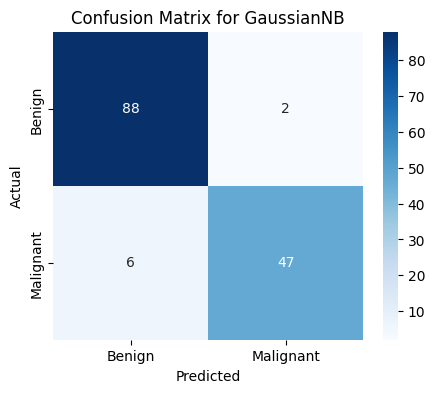

              precision    recall  f1-score   support

      Benign       0.94      0.98      0.96        90
   Malignant       0.96      0.89      0.92        53

    accuracy                           0.94       143
   macro avg       0.95      0.93      0.94       143
weighted avg       0.94      0.94      0.94       143

5-fold Cross-Validation Accuracy: 0.9279

========== KNN ==========


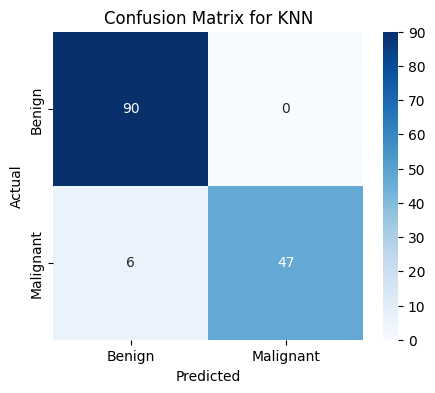

              precision    recall  f1-score   support

      Benign       0.94      1.00      0.97        90
   Malignant       1.00      0.89      0.94        53

    accuracy                           0.96       143
   macro avg       0.97      0.94      0.95       143
weighted avg       0.96      0.96      0.96       143

5-fold Cross-Validation Accuracy: 0.9578

========== SVM ==========


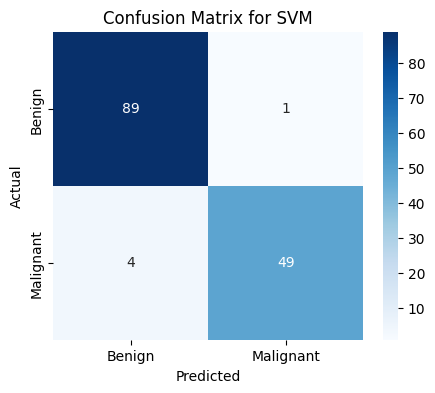

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        90
   Malignant       0.98      0.92      0.95        53

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143

5-fold Cross-Validation Accuracy: 0.9772


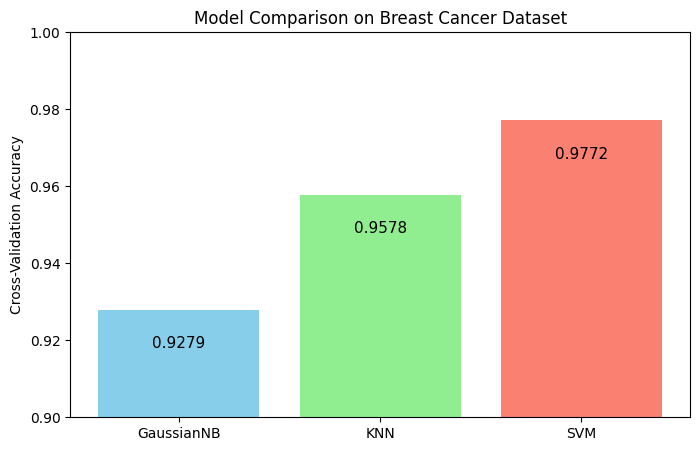

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
import os

# --------------------------
# 1. Load and preprocess data
# --------------------------
data = pd.read_csv("breast.csv")
data.drop(columns=["Unnamed: 32", "id"], inplace=True)
data.rename(columns={"diagnosis": "target"}, inplace=True)
data["target"] = data["target"].map(lambda x: 1 if x.strip()=='M' else 0)

y = data["target"]
X = data.drop(["target"], axis=1)

# --------------------------
# 2. Split and scale data
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --------------------------
# 3. Create images folder if it doesn't exist
# --------------------------
if not os.path.exists("images"):
    os.makedirs("images")

# --------------------------
# 4. Define models
# --------------------------
models = {}

# GaussianNB
gnb = GaussianNB()
models['GaussianNB'] = gnb

# KNN with GridSearchCV
param_grid_knn = {'n_neighbors': range(1,15)}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5)
grid_knn.fit(X_train_scaled, y_train)
best_knn = grid_knn.best_estimator_
models['KNN'] = best_knn

# SVM with GridSearchCV
param_grid_svc = {'C':[0.1,1,10,100],'kernel':['linear','rbf','poly'],'gamma':['scale','auto']}
grid_svc = GridSearchCV(SVC(), param_grid_svc, cv=5)
grid_svc.fit(X_train_scaled, y_train)
best_svc = grid_svc.best_estimator_
models['SVM'] = best_svc

# --------------------------
# 5. Evaluate models and save images
# --------------------------
cv_accuracies = []

for name, model in models.items():
    print(f"\n========== {name} ==========")
    
    # Train GaussianNB (others already trained)
    if name == 'GaussianNB':
        model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign','Malignant'], yticklabels=['Benign','Malignant'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix for {name}')
    plt.savefig(f'images/cm_{name}.png')
    plt.show()
    
    # Classification report
    print(classification_report(y_test, y_pred, target_names=['Benign','Malignant']))
    
    # Cross-validation
    cv_score = cross_val_score(model, scaler.fit_transform(X), y, cv=5).mean()
    cv_accuracies.append(cv_score)
    print(f"5-fold Cross-Validation Accuracy: {cv_score:.4f}")
    
    # Best parameters if available
    if hasattr(model, 'best_params_'):
        print(f"Best Parameters: {model.best_params_}")

# --------------------------
# 6. Summary comparison plot
# --------------------------
plt.figure(figsize=(8,5))
bars = plt.bar(models.keys(), cv_accuracies, color=['skyblue','lightgreen','salmon'])
plt.ylim(0.9, 1.0)
plt.ylabel('Cross-Validation Accuracy')
plt.title('Model Comparison on Breast Cancer Dataset')

# Add accuracy labels
for bar, acc in zip(bars, cv_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()-0.01, f"{acc:.4f}", ha='center', color='black', fontsize=11)

plt.savefig('images/summary_plot.png')
plt.show()